In [1]:
import radiate as rd
import polars as pl
from IPython.display import display, HTML


# import polars as pl  # type: ignore
import matplotlib.pyplot as plt  # type: ignore

rd.random.seed(67123)


In [ ]:
class ScorePlotterHandler(rd.EventHandler):
    def __init__(self):
        super().__init__()
        self.scores = []

    def on_event(self, event: rd.EngineEvent) -> None:
        if event.event_type() == rd.EventType.EPOCH_COMPLETE:
            best_score = event.score()
            self.scores.append(best_score)
        elif event.event_type() == rd.EventType.STOP:
            plt.plot(list(range(len(self.scores))), self.scores)
            plt.xlabel("Generation")
            plt.ylabel("Best Score")
            plt.title("Best Score over Generations")
            plt.grid(True)
            plt.show()


def compute(x: float) -> float:
    return 4.0 * x**3 - 3.0 * x**2 + x


inputs = []
answers = []

input = -1.0
for _ in range(-10, 10):
    input += 0.1
    inputs.append([input])
    answers.append([compute(input)])

2026-04-09T15:41:37.172344Z  INFO Epoch 1    | Score:   2.0038 | Time: 228.58µs
2026-04-09T15:41:37.172530Z  INFO Epoch 2    | Score:   2.0038 | Time: 298.25µs
2026-04-09T15:41:37.172698Z  INFO Epoch 3    | Score:   2.0038 | Time: 360.96µs
2026-04-09T15:41:37.172867Z  INFO Epoch 4    | Score:   1.6821 | Time: 418.04µs
2026-04-09T15:41:37.173042Z  INFO Epoch 5    | Score:   1.6821 | Time: 484.96µs
2026-04-09T15:41:37.173221Z  INFO Epoch 6    | Score:   1.6821 | Time: 557.96µs
2026-04-09T15:41:37.173405Z  INFO Epoch 7    | Score:   1.6821 | Time: 635.96µs
2026-04-09T15:41:37.173583Z  INFO Epoch 8    | Score:   1.6821 | Time: 709.33µs
2026-04-09T15:41:37.173769Z  INFO Epoch 9    | Score:   1.6821 | Time: 787.75µs
2026-04-09T15:41:37.173951Z  INFO Epoch 10   | Score:   1.6821 | Time: 858.75µs
2026-04-09T15:41:37.174129Z  INFO Epoch 11   | Score:   1.6821 | Time: 937.33µs
2026-04-09T15:41:37.174304Z  INFO Epoch 12   | Score:   1.6821 | Time: 1.01ms
2026-04-09T15:41:37.174481Z  INFO Epoch 13

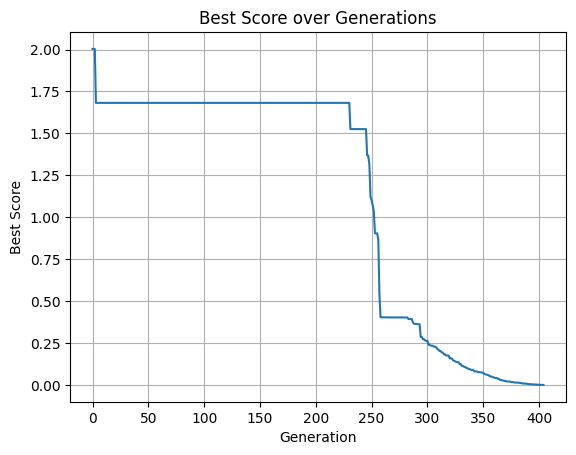

In [3]:
subscriber = ScorePlotterHandler()
collector = rd.MetricCollector()

engine = (
    rd.Engine.graph(
        shape=(1, 1),
        vertex=[rd.Op.sub(), rd.Op.mul(), rd.Op.linear()],
        edge=rd.Op.weight(),
        output=rd.Op.linear(),
    )
    .regression(inputs, answers, loss=rd.MSE)
    .subscribe(subscriber, collector)
    .alters(
        rd.Cross.graph(0.05, 0.5),
        rd.Mutate.op(0.07, 0.05),
        rd.Mutate.graph(0.1, 0.1, False),
    )
    .limit(rd.Limit.generations(1000), rd.Limit.score(0.001))
)

result = engine.run(log=True)

In [4]:
eval_results = result.value().eval(inputs)
accuracy = rd.accuracy(result.value(), inputs, answers, loss=rd.MSE)

print(result)
print(result.metrics().dashboard())
print(accuracy)


(
	index=405,
	score=[0.00079838],
	dtype=Node(Op32),
	MetricSet[metrics=39, updates=79638],
	value=Graph(
[0  ] [5005   ] "Inp" :: Zero  Var: X0(0)   V:true  R:false 0  12 < []
[1  ] [5007   ] "Out" :: Any   Fn: linear   V:true  R:false 9  0  < [0, 2, 4, 5, 8, 12, 13, 14, 17]
[2  ] [3258   ] "Ver" :: Any   Fn: linear   V:true  R:false 2  1  < [0, 3]
[3  ] [5010   ] "Ver" :: Any   Fn: linear   V:true  R:false 2  2  < [0, 8]
[4  ] [5012   ] "Ver" :: 2     Fn: sub      V:true  R:false 2  2  < [3, 11]
[5  ] [6007   ] "Edg" :: 1     Val: w(-0.9644501) V:true  R:false 1  1  < [4]
[6  ] [7097   ] "Edg" :: 1     Val: w(-0.75085896) V:true  R:false 1  1  < [7]
[7  ] [7139   ] "Ver" :: Any   Fn: linear   V:true  R:false 3  1  < [0, 9, 11]
[8  ] [7188   ] "Ver" :: 2     Fn: mul      V:true  R:false 2  2  < [0, 15]
[9  ] [7225   ] "Ver" :: Any   Fn: linear   V:true  R:false 1  1  < [0]
[10 ] [7483   ] "Edg" :: 1     Val: w(-2.515046) V:true  R:false 1  1  < [0]
[11 ] [7578   ] "Ver" :: 2     Fn: 

In [5]:
df = collector.to_polars(lazy=False)
df


name,last,sum,mean,stddev,var,skew,min,max,count,time_sum,time_mean,time_stddev,time_min,time_max,time_var,version,update_count,tags
str,f64,f64,f64,f64,f64,f64,f64,f64,i64,duration[μs],duration[μs],duration[μs],duration[μs],duration[μs],duration[μs],i64,i64,list[str]
"""evaluate_step""",0.0,null,null,null,null,null,null,null,2,82µs,41µs,42µs,11µs,71µs,0µs,1,2,"[""time"", ""step""]"
"""tournament_selector""",80.0,80.0,80.0,0.0,0.0,NaN,80.0,80.0,1,10µs,10µs,0µs,10µs,10µs,0µs,1,2,"[""selector"", ""statistic"", ""time""]"
"""lineage_top1_pair_share""",0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,1,null,null,null,null,null,null,1,1,"[""age"", ""statistic"", ""lineage""]"
"""filter_step""",0.0,null,null,null,null,null,null,null,1,2µs,2µs,0µs,2µs,2µs,0µs,1,1,"[""time"", ""step""]"
"""alter_parent_reuse""",1.0,8.0,1.142857,0.377964,0.142857,0.0,1.0,2.0,7,null,null,null,null,null,null,1,7,"[""alterer"", ""statistic"", … ""lineage""]"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""graph_mutator_rate""",1.0,405.0,1.0,0.0,0.0,0.0,1.0,1.0,405,null,null,null,null,null,null,405,1,"[""alterer"", ""mutator"", … ""rate""]"
"""graph_mut_failure""",1.0,915.0,1.0,0.0,0.0,0.0,1.0,1.0,915,null,null,null,null,null,null,405,2,"[""failure"", ""statistic""]"
"""recombine_step""",0.0,null,null,null,null,null,null,null,405,24587µs,60µs,21µs,34µs,143µs,0µs,405,1,"[""time"", ""step""]"


In [6]:
filtered = (
    df.filter(pl.col("name") == "best_score_improvement")
    .select("version")
    .unique()
    .sort("version")
)
filtered

version
i64
4
232
247
248
249
…
397
398
400


In [7]:
display(HTML(filtered._repr_html_()))

version
i64
4
232
247
248
249
…
397
398
400
